In [ ]:
!pip install wandb

In [ ]:
import wandb


## **5 Steps from Previous Model**

Image batch Shape: (16, 224, 224, 3)
Label batch Shape: (16,)
Labels: [0 1 1 1 0 2 1 0 4 3 0 3 1 4 4 1]


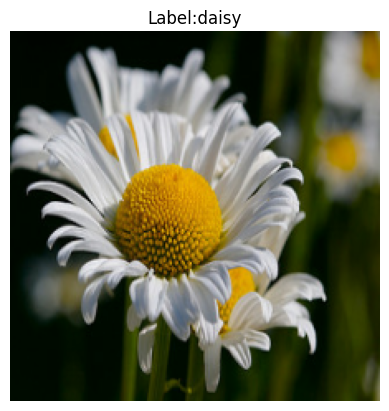

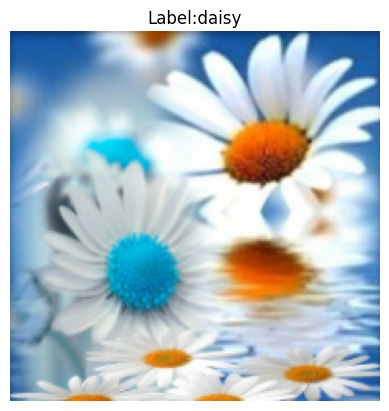

In [1]:
import tensorflow as tf
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

# we are using predefined function from TensorFlow

def read_and_decode(filename, resize_dims):
  # 1. Read the raw file
  img_bytes = tf.io.read_file(filename)

  #2. Decode image data
  img = tf.image.decode_jpeg(img_bytes, channels = IMG_CHANNELS)

  #3. Convert pixel values to floats in [0,1]
  img = tf.image.convert_image_dtype(img, tf.float32)

  #4. Resize the image to match desired dimentions
  img = tf.image.resize(img,resize_dims)

  return img

def parse_csvline(csv_line):

  # record_default specify the data types for each column
  record_default = ["",""]
  filename, label_string = tf.io.decode_csv(csv_line, record_default)

  #Load the Image
  img  = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])

  # Convert label string to integer based on the CLASS_NAMES index
  label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))


  return img, label


# Define datasets
train_dataset = (
    tf.data.TextLineDataset("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
  )          # we defined batch size = 16

eval_dataset = (
    tf.data.TextLineDataset("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

for image_batch, label_batch in train_dataset.take(1):
  print("Image batch Shape:", image_batch.shape)
  print("Label batch Shape:", label_batch.shape)
  print("Labels:", label_batch.numpy())


import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(2):

  #Take the first image from the batch
  first_image = image_batch[0]
  first_label = label_batch[0]


  # Conver Tensor To Numpy array
  plt.imshow(first_image.numpy())
  plt.title(f"Label:{CLASS_NAMES[first_label]}")
  plt.axis('off')
  plt.show()


# New Model With 2 Hidden Layer

In [2]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

model= keras.Sequential([
    keras.layers.Flatten(input_shape = (IMG_HEIGHT, IMG_WIDTH,3)),
    tf.keras.layers.Dense(128, activation = "relu"),
    #This is the anather layer we have added for convolution.   ---> makes 15 million +  trainable parameters

    keras.layers.Dense(len(CLASS_NAMES), activation = "softmax")
])

model.compile(
    optimizer = "adam",
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ["accuracy"]
)



C:\PYTHON_ENV\env_object_detection\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Training and Validation

In [3]:
# Optimizing learning rate as per the requirements

model.compile(
    optimizer = Adam(learning_rate = 0.1),
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ["accuracy"]
)


In [4]:
EPOCHS = 5

history = model.fit(
    train_dataset,
    validation_data = eval_dataset,
    epochs = EPOCHS
)

Epoch 1/5
    207/Unknown 215s 1s/step - accuracy: 0.2338 - loss: 1191.3255

C:\PYTHON_ENV\env_object_detection\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


207/207 ━━━━━━━━━━━━━━━━━━━━ 428s 2s/step - accuracy: 0.2358 - loss: 281.6714 - val_accuracy: 0.2458 - val_loss: 1.6405
Epoch 2/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.2355 - loss: 1.6522 - val_accuracy: 0.2458 - val_loss: 1.5996
Epoch 3/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 432s 2s/step - accuracy: 0.2355 - loss: 1.6121 - val_accuracy: 0.2458 - val_loss: 1.5997
Epoch 4/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.2355 - loss: 1.6124 - val_accuracy: 0.2458 - val_loss: 1.5997
Epoch 5/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.2336 - loss: 1.6125 - val_accuracy: 0.2458 - val_loss: 1.5997


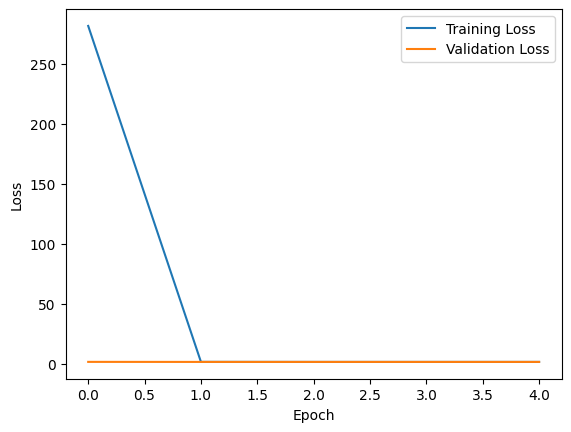

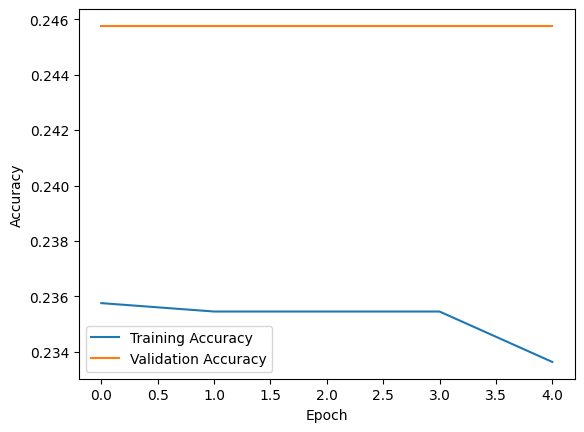

In [5]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Testing with Batch size 1

Image batch Shape: (1, 224, 224, 3)
Label batch Shape: (1,)
Labels: [0]


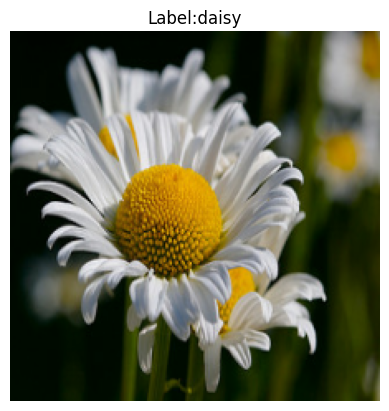

Epoch 1/3
   1413/Unknown 190s 132ms/step - accuracy: 0.1997 - loss: 1089.7744

In [ ]:
import tensorflow as tf
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

# we are using predefined function from TensorFlow

def read_and_decode(filename, resize_dims):

  img_bytes = tf.io.read_file(filename)

  img = tf.image.decode_jpeg(img_bytes, channels = IMG_CHANNELS)


  img = tf.image.convert_image_dtype(img, tf.float32)

  img = tf.image.resize(img,resize_dims)

  return img

def parse_csvline(csv_line):

  # record_default specify the data types for each column
  record_default = ["",""]
  filename, label_string = tf.io.decode_csv(csv_line, record_default)

  #Load the Image
  img  = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])

  # Convert label string to integer based on the CLASS_NAMES index
  label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))


  return img, label


# Define datasets
train_dataset = (
    tf.data.TextLineDataset("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(1)
    .prefetch(tf.data.AUTOTUNE)
  )          # we defined batch size = 16

eval_dataset = (
    tf.data.TextLineDataset("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(1)
    .prefetch(tf.data.AUTOTUNE)
)

for image_batch, label_batch in train_dataset.take(1):
  print("Image batch Shape:", image_batch.shape)
  print("Label batch Shape:", label_batch.shape)
  print("Labels:", label_batch.numpy())


import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(1):

  #Take the first image from the batch
  first_image = image_batch[0]
  first_label = label_batch[0]


  # Conver Tensor To Numpy array
  plt.imshow(first_image.numpy())
  plt.title(f"Label:{CLASS_NAMES[first_label]}")
  plt.axis('off')
  plt.show()


from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

model= keras.Sequential([
    keras.layers.Flatten(input_shape = (IMG_HEIGHT, IMG_WIDTH,3)),
    tf.keras.layers.Dense(128, activation = "relu"),
    #This is the anather layer we have added for convolution.   ---> makes 15 million +  trainable parameters

    keras.layers.Dense(len(CLASS_NAMES), activation = "softmax")
])

model.compile(
    optimizer = Adam(learning_rate = 0.1),
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ["accuracy"]
)

EPOCHS = 3

history = model.fit(
    train_dataset,
    validation_data = eval_dataset,
    epochs = EPOCHS
)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Testing with Batch Size 224 x 224 , 64 , 0.001

Image batch Shape: (64, 224, 224, 3)
Label batch Shape: (64,)
Labels: [0 1 1 1 0 2 1 0 4 3 0 3 1 4 4 1 0 3 2 1 0 4 2 0 2 2 1 3 3 2 1 0 3 1 1 1 1
 0 1 2 4 3 3 2 0 1 4 0 0 3 2 3 0 4 1 0 4 4 0 3 2 3 2 3]


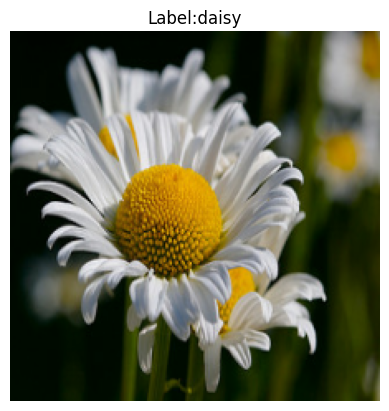

Epoch 1/3
52/52 ━━━━━━━━━━━━━━━━━━━━ 375s 7s/step - accuracy: 0.3294 - loss: 17.8984 - val_accuracy: 0.4200 - val_loss: 3.2266
Epoch 2/3
52/52 ━━━━━━━━━━━━━━━━━━━━ 375s 7s/step - accuracy: 0.4021 - loss: 3.4827 - val_accuracy: 0.3412 - val_loss: 4.2639
Epoch 3/3
52/52 ━━━━━━━━━━━━━━━━━━━━ 379s 7s/step - accuracy: 0.4142 - loss: 3.4224 - val_accuracy: 0.3988 - val_loss: 2.8982


In [8]:
import tensorflow as tf
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

# we are using predefined function from TensorFlow

def read_and_decode(filename, resize_dims):

  img_bytes = tf.io.read_file(filename)

  img = tf.image.decode_jpeg(img_bytes, channels = IMG_CHANNELS)


  img = tf.image.convert_image_dtype(img, tf.float32)

  img = tf.image.resize(img,resize_dims)

  return img

def parse_csvline(csv_line):

  # record_default specify the data types for each column
  record_default = ["",""]
  filename, label_string = tf.io.decode_csv(csv_line, record_default)

  #Load the Image
  img  = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])

  # Convert label string to integer based on the CLASS_NAMES index
  label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))


  return img, label


# Define datasets
train_dataset = (
    tf.data.TextLineDataset("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
  )          # we defined batch size = 16

eval_dataset = (
    tf.data.TextLineDataset("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

for image_batch, label_batch in train_dataset.take(1):
  print("Image batch Shape:", image_batch.shape)
  print("Label batch Shape:", label_batch.shape)
  print("Labels:", label_batch.numpy())


import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(1):

  #Take the first image from the batch
  first_image = image_batch[0]
  first_label = label_batch[0]


  # Conver Tensor To Numpy array
  plt.imshow(first_image.numpy())
  plt.title(f"Label:{CLASS_NAMES[first_label]}")
  plt.axis('off')
  plt.show()


from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

model= keras.Sequential([
    keras.layers.Flatten(input_shape = (IMG_HEIGHT, IMG_WIDTH,3)),
    tf.keras.layers.Dense(128, activation = "relu"),
    #This is the anather layer we have added for convolution.   ---> makes 15 million +  trainable parameters

    keras.layers.Dense(len(CLASS_NAMES), activation = "softmax")
])

model.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ["accuracy"]
)

EPOCHS = 3

history = model.fit(
    train_dataset,
    validation_data = eval_dataset,
    epochs = EPOCHS
)

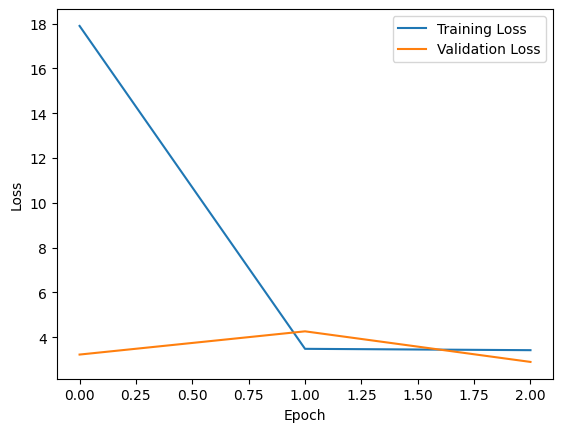

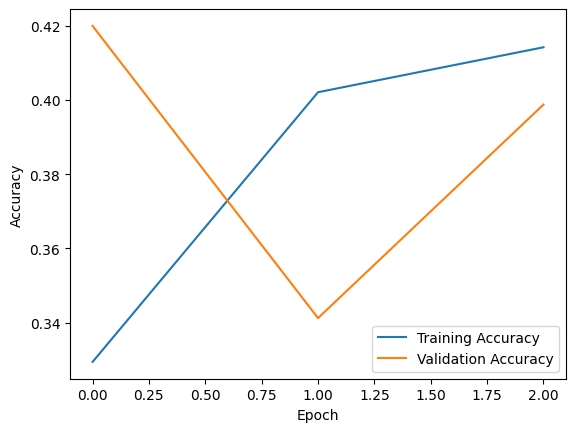

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Testing with batch size 16 x 16, 64 , 0.001

Image batch Shape: (64, 16, 16, 3)
Label batch Shape: (64,)
Labels: [0 1 1 1 0 2 1 0 4 3 0 3 1 4 4 1 0 3 2 1 0 4 2 0 2 2 1 3 3 2 1 0 3 1 1 1 1
 0 1 2 4 3 3 2 0 1 4 0 0 3 2 3 0 4 1 0 4 4 0 3 2 3 2 3]


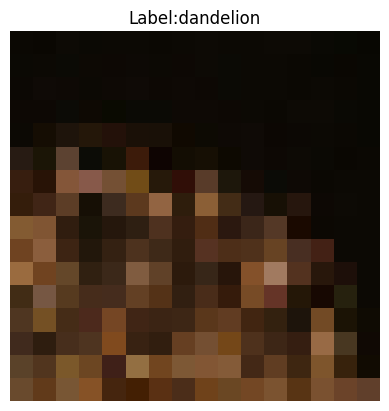

Epoch 1/3
52/52 ━━━━━━━━━━━━━━━━━━━━ 349s 7s/step - accuracy: 0.3615 - loss: 1.4516 - val_accuracy: 0.4285 - val_loss: 1.3167
Epoch 2/3
52/52 ━━━━━━━━━━━━━━━━━━━━ 352s 7s/step - accuracy: 0.4591 - loss: 1.2905 - val_accuracy: 0.4803 - val_loss: 1.2258
Epoch 3/3
52/52 ━━━━━━━━━━━━━━━━━━━━ 377s 7s/step - accuracy: 0.4824 - loss: 1.2347 - val_accuracy: 0.5182 - val_loss: 1.1806


In [10]:
import tensorflow as tf
IMG_HEIGHT = 16
IMG_WIDTH = 16
IMG_CHANNELS = 3
CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

# we are using predefined function from TensorFlow

def read_and_decode(filename, resize_dims):

  img_bytes = tf.io.read_file(filename)

  img = tf.image.decode_jpeg(img_bytes, channels = IMG_CHANNELS)


  img = tf.image.convert_image_dtype(img, tf.float32)

  img = tf.image.resize(img,resize_dims)

  return img

def parse_csvline(csv_line):

  # record_default specify the data types for each column
  record_default = ["",""]
  filename, label_string = tf.io.decode_csv(csv_line, record_default)

  #Load the Image
  img  = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])

  # Convert label string to integer based on the CLASS_NAMES index
  label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))


  return img, label


# Define datasets
train_dataset = (
    tf.data.TextLineDataset("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
  )          # we defined batch size = 64

eval_dataset = (
    tf.data.TextLineDataset("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

for image_batch, label_batch in train_dataset.take(1):
  print("Image batch Shape:", image_batch.shape)
  print("Label batch Shape:", label_batch.shape)
  print("Labels:", label_batch.numpy())


import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(1):

  #Take the first image from the batch
  first_image = image_batch[2]
  first_label = label_batch[2]


  # Conver Tensor To Numpy array
  plt.imshow(first_image.numpy())
  plt.title(f"Label:{CLASS_NAMES[first_label]}")
  plt.axis('off')
  plt.show()


from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

model= keras.Sequential([
    keras.layers.Flatten(input_shape = (IMG_HEIGHT, IMG_WIDTH,3)),
    tf.keras.layers.Dense(128, activation = "relu"),
    #This is the anather layer we have added for convolution.   ---> makes 15 million +  trainable parameters

    keras.layers.Dense(len(CLASS_NAMES), activation = "softmax")
])

model.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ["accuracy"]
)

EPOCHS = 3

history = model.fit(
    train_dataset,
    validation_data = eval_dataset,
    epochs = EPOCHS
)

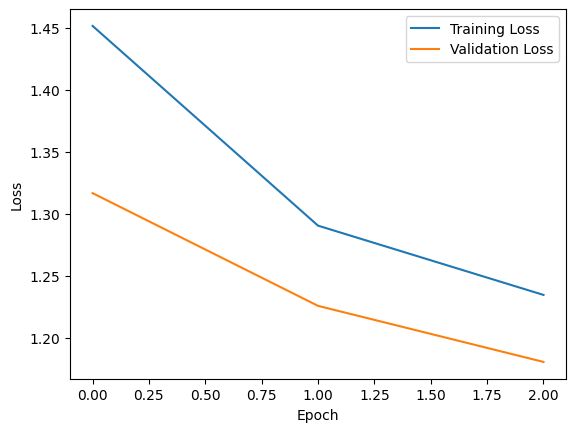

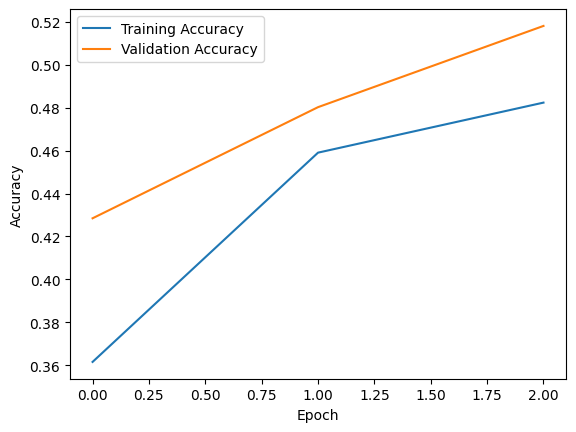

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Testing with batch size 16 x 16, 16 , 0.001

Image batch Shape: (16, 16, 16, 3)
Label batch Shape: (16,)
Labels: [0 1 1 1 0 2 1 0 4 3 0 3 1 4 4 1]


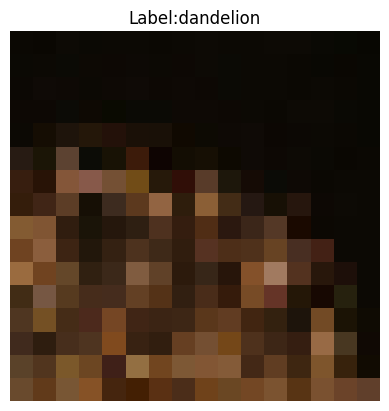

Epoch 1/3
207/207 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.3797 - loss: 1.4198 - val_accuracy: 0.4552 - val_loss: 1.2704
Epoch 2/3
207/207 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.4573 - loss: 1.2604 - val_accuracy: 0.5024 - val_loss: 1.1870
Epoch 3/3
207/207 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.4964 - loss: 1.1949 - val_accuracy: 0.5103 - val_loss: 1.1571


In [12]:
import tensorflow as tf
IMG_HEIGHT = 16
IMG_WIDTH = 16
IMG_CHANNELS = 3
CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

# we are using predefined function from TensorFlow

def read_and_decode(filename, resize_dims):

  img_bytes = tf.io.read_file(filename)

  img = tf.image.decode_jpeg(img_bytes, channels = IMG_CHANNELS)


  img = tf.image.convert_image_dtype(img, tf.float32)

  img = tf.image.resize(img,resize_dims)

  return img

def parse_csvline(csv_line):

  # record_default specify the data types for each column
  record_default = ["",""]
  filename, label_string = tf.io.decode_csv(csv_line, record_default)

  #Load the Image
  img  = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])

  # Convert label string to integer based on the CLASS_NAMES index
  label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))


  return img, label


# Define datasets
train_dataset = (
    tf.data.TextLineDataset("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
  )          # we defined batch size = 64

eval_dataset = (
    tf.data.TextLineDataset("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

for image_batch, label_batch in train_dataset.take(1):
  print("Image batch Shape:", image_batch.shape)
  print("Label batch Shape:", label_batch.shape)
  print("Labels:", label_batch.numpy())


import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(1):

  #Take the first image from the batch
  first_image = image_batch[2]
  first_label = label_batch[2]


  # Conver Tensor To Numpy array
  plt.imshow(first_image.numpy())
  plt.title(f"Label:{CLASS_NAMES[first_label]}")
  plt.axis('off')
  plt.show()


from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

model= keras.Sequential([
    keras.layers.Flatten(input_shape = (IMG_HEIGHT, IMG_WIDTH,3)),
    tf.keras.layers.Dense(128, activation = "relu"),
    #This is the anather layer we have added for convolution.   ---> makes 15 million +  trainable parameters

    keras.layers.Dense(len(CLASS_NAMES), activation = "softmax")
])

model.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ["accuracy"]
)

EPOCHS = 3

history = model.fit(
    train_dataset,
    validation_data = eval_dataset,
    epochs = EPOCHS
)

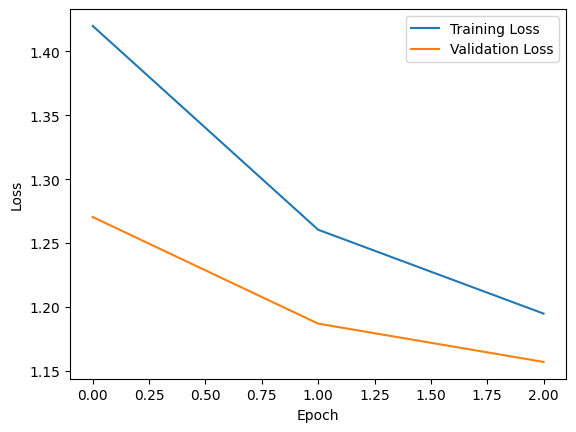

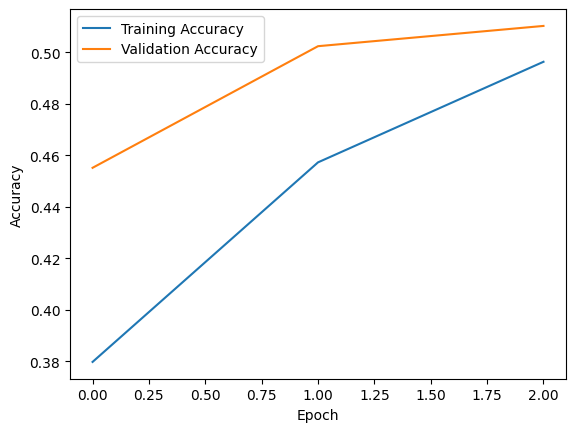

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()